# 03. Deterministic baselines & lookback selection

**Context**
- EDA (NB02) showed most tracks near-rectilinear (straightness mostly **> 0.8**).
- Difficulty is regime-dependent (stationary, rectilinear, non-linear).
- Horizon length controls the regime mix in a window.

**Objective**
- Test geometric extrapolation as a baseline across horizons.
- Fix one lookback usable for all horizons.
- Test whether curvature helps analytically (quadratic).

**Outcome**
- Linear constant-velocity extrapolation kept as baseline.
- Lookback fixed at **12h** although short lookbacks are marginally better, to keep one preprocessing for all horizons and leave headroom for learned models.
- Quadratic strictly dominated by linear.
- The future position is not the geometric continuation of the past shape, which motivates learned models (NB04).

Input: cleaned, resampled, vessel-split data using the workflow determined in NB02 (EDA)


## Contents

1. Setup
2. Linear extrapolation
3. Quadratic extrapolation
4. Conclusions


## 1. Setup


In [2]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vessel_tracker.config import settings
from vessel_tracker.paths import DATA_PROCESSED
from vessel_tracker.preprocessing import vessel_train_test_split
from vessel_tracker.metrics import haversine_distance

# --- Load cleaned + resampled dataset (NB02) ---
processed_path = DATA_PROCESSED / f"AIS_clean_resampled_{settings.resample_interval_min}min.parquet"
df = pd.read_parquet(processed_path)
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])
print(f"Loaded: {len(df):,} rows, {df['MMSI'].nunique():,} vessels")

# --- Replay the split (same seed → same partition as NB02) ---
df_train, df_val, df_test, *_ = vessel_train_test_split(
    df,
    test_size=settings.split_ratios.test,
    val_size=settings.split_ratios.val,
    random_state=settings.random_seed,
)
print(f"Train: {df_train['MMSI'].nunique():,} vessels | "
      f"Val: {df_val['MMSI'].nunique():,} | Test: {df_test['MMSI'].nunique():,}")


Loaded: 3,661,057 rows, 2,173 vessels
Train: 1,521 vessels | Val: 326 | Test: 326


In [3]:
candidates_horizon = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 34, 40, 44, 48, 54, 60, 66, 72]
candidates_lookback = [1,3,6,12,24]
#in hours

## 2. Linear extrapolation

 It assumes the vessel holds its current course and speed.
We calculate the LAT/LON displacement over the lookback, divide by its
duration, and extrapolated over the horizon. 

Evaluation: 
- rolling windows. 
- Error: haversine MAE (km), 
- Also reported as a percentage of net displacement so horizons are comparable.
(a 5km error over 100k displacement doesn't have the same meaning that the same error over 10km displacement)


In [4]:
results = []
for l in candidates_lookback:
    l_steps = l * 60 // settings.resample_interval_min
    print(f"testing {l}h of lookback")
    #calculating baseline for each lookback
    for h in candidates_horizon:
        h_steps = h * 60 // settings.resample_interval_min
        shifted = df_train.copy()
        shifted["LAT_start"] = df_train.groupby("MMSI")["LAT"].shift(l_steps) # position at beginning of lookback
        shifted["LON_start"] = df_train.groupby("MMSI")["LON"].shift(l_steps)
        shifted["LAT_target"] = df_train.groupby("MMSI")["LAT"].shift(-h_steps)
        shifted["LON_target"] = df_train.groupby("MMSI")["LON"].shift(-h_steps) #position at horizon
        shifted = shifted.dropna(subset=["LAT_start", "LON_start", "LAT_target", "LON_target"])

        # linear extrapolation of the LAT/LON delta over the lookback
        velocity_LAT = (shifted["LAT"] - shifted["LAT_start"]) / l_steps
        velocity_LON = (shifted["LON"] - shifted["LON_start"]) / l_steps
        LAT_pred = shifted["LAT"] + velocity_LAT * h_steps
        LON_pred = shifted["LON"] + velocity_LON * h_steps

        error_km = haversine_distance(
            shifted["LAT_target"], shifted["LON_target"], LAT_pred, LON_pred
        )
        mae = error_km.mean()

        # travelled distance present→target (great-circle), as the relative-error denominator
        net_displacement_km = haversine_distance(
            shifted["LAT"], shifted["LON"], shifted["LAT_target"], shifted["LON_target"]
        )
        mae_pct = 100 * mae / net_displacement_km.mean()

        results.append({
            "lookback": l,
            "horizon": h,
            "mae": mae,
            "mae_pct": mae_pct,
            "n_tracks": len(shifted),
            "n_vessels": shifted["MMSI"].nunique(),
        })

results_df = pd.DataFrame(results)


testing 1h of lookback
testing 3h of lookback
testing 6h of lookback
testing 12h of lookback
testing 24h of lookback


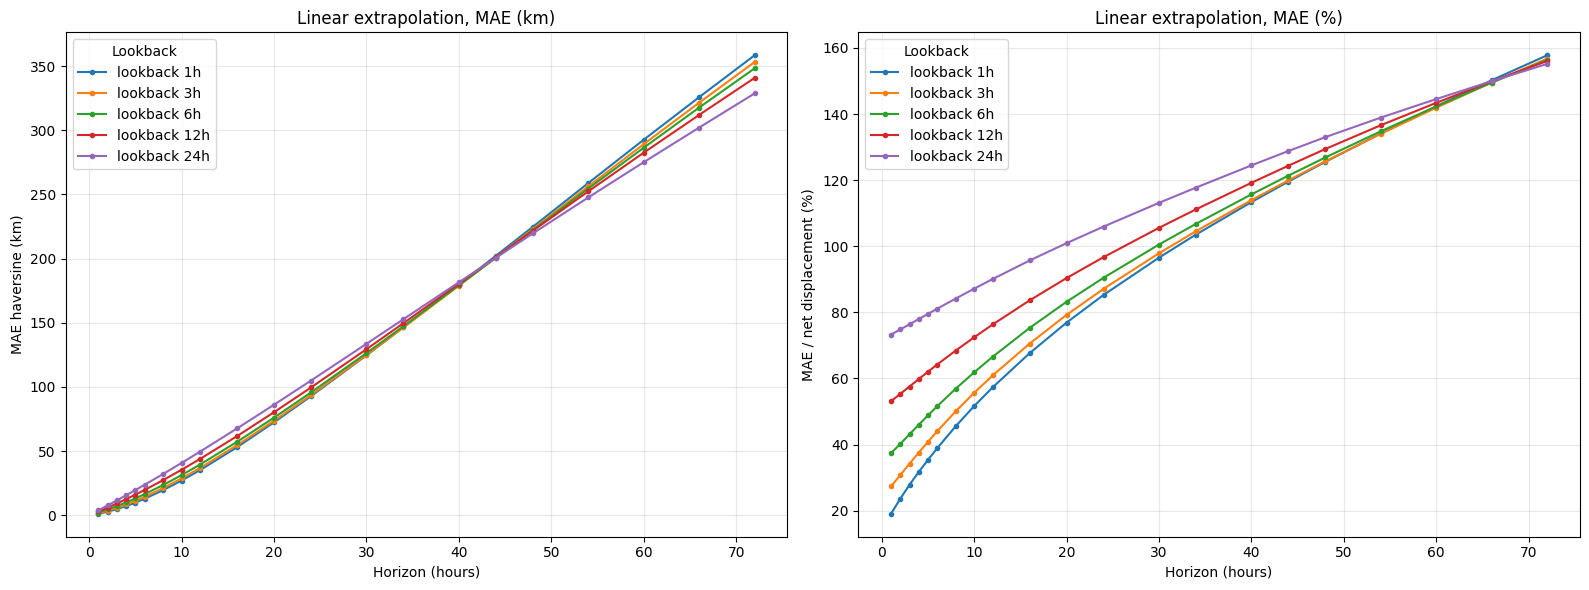

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for l in candidates_lookback:
    subset = results_df[results_df["lookback"] == l]
    axes[0].plot(subset["horizon"], subset["mae"], marker="o", markersize=3, label=f"lookback {l}h")
    axes[1].plot(subset["horizon"], subset["mae_pct"], marker="o", markersize=3, label=f"lookback {l}h")

axes[0].set_xlabel("Horizon (hours)")
axes[0].set_ylabel("MAE haversine (km)")
axes[0].set_title("Linear extrapolation, MAE (km)")
axes[0].legend(title="Lookback")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Horizon (hours)")
axes[1].set_ylabel("MAE / net displacement (%)")
axes[1].set_title("Linear extrapolation, MAE (%)")
axes[1].legend(title="Lookback")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# TABLE OF MAE AT EACH HORIZON BY LOOKBACK DURATION
pivot_mae = results_df.pivot(index="horizon", columns="lookback", values="mae").round(1)
pivot_mae.columns = [f"L={c}h" for c in pivot_mae.columns]
display(pivot_mae)



,L=1h,L=3h,L=6h,L=12h,L=24h
horizon,,,,,
1,1.1,1.6,2.1,2.9,3.8
2,2.8,3.5,4.5,6.0,7.7
3,4.8,5.8,7.2,9.2,11.6
4,7.2,8.4,10.0,12.6,15.6
5,9.9,11.2,13.1,16.1,19.7
6,12.9,14.3,16.4,19.7,23.8
8,19.6,21.2,23.6,27.4,32.2
10,27.1,28.7,31.3,35.5,40.8
12,35.2,36.9,39.5,43.9,49.6


In [7]:
# TABLE OF MAE AS PCT OF DISPLACEMENT AT EACH HORIZON BY LOOKBACK DURATION
pivot_pct = results_df.pivot(index="horizon", columns="lookback", values="mae_pct").round(1)
pivot_pct.columns = [f"L={c}h" for c in pivot_pct.columns]
display(pivot_pct)

,L=1h,L=3h,L=6h,L=12h,L=24h
horizon,,,,,
1,19.1,27.4,37.4,53.1,73.3
2,23.6,30.8,40.2,55.3,74.8
3,27.8,34.2,43.1,57.6,76.4
4,31.7,37.6,46.0,59.8,78.0
5,35.4,40.8,48.8,62.0,79.5
6,38.9,44.0,51.6,64.2,81.1
8,45.5,50.1,56.9,68.4,84.2
10,51.7,55.7,61.9,72.5,87.2
12,57.3,60.9,66.6,76.3,90.1


### 2.1 Lookback selection


Short lookbacks dominate at short/mid term (1–24h); long lookbacks only overtake
beyond ~40h, where both predictors are already poor. Interpretation: a short lookback captures
the recent course (local derivative), a long one captures the mean transit heading (global
trend) that only helps at multi-day horizons. 

Baseline result: a short lookback is better for the baseline itself (at a 1h horizon, 1.1 km with a 1h lookback vs 2.9 km with 12h). The gap stays small in absolute km.

Workflow decision: we still fix lookback at 12h for every horizon and every later model, with a 3h spot check retained. The reason is that the long lookback only causes a small increase of error in absolute kilometers at short horizons, and may contain more information for other, more complex model. 

Above 8h, the MAE errors are in tens of km already. The linear baseline stays a useful reference, but these levels are already too large for operational use. In the next part, we'll check whether this is due to a lack of accounting for trajectory curvature using quadratic extrapolation instead. 




## 3. Quadratic extrapolation

Hypothesis: we need a baseline that includes curvature. Over the lookback we approximate each coordinate $y(t)$ (LAT or LON, separately) as a quadratic function of time:

$$
y(t) \approx a\, t^2 + b\, t + c
$$

With lookback times $t = 0, \ldots, L$ and observed positions $y = (y_0, \ldots, y_L)$, we minimize the residual between the observations and the fitted values:

$$
\min_\theta \|y - \hat{y}\|^2 = \min_\theta \|y - V\theta\|^2
$$

where $V$ is the Vandermonde matrix of the lookback times, shape $(L+1,\ 3)$ (one row per $t$: $[t^2,\ t,\ 1]$), and $\theta = (a, b, c)$.

In closed form, $\theta = V^{+} y$, with $V^{+}$ the pseudo-inverse of $V$ (shape $(3,\ L+1)$).

For prediction at $t_* = L + H$ (present + horizon):

$$
\hat{y}(t_*) = V(t_*)\, \theta = V(t_*)\, V^{+}\, y = w^\top y
$$

where $V(t_*) = [t_*^2,\ t_*,\ 1]$ (shape $(3,)$) and $w^\top = V(t_*)\, V^{+}$ (shape $(L+1,)$).

**Important for the code:** we never compute $\theta = (a,b,c)$. Because $V$ and $V(t_*)$ depend only on the time grid, $w$ is constant for a fixed lookback and horizon. 


In [8]:
def quadratic_extrapolation_weights(l_steps, h_steps):
    """
    Precompute w such that y_pred(t*) = w @ y_lookback.

    Skips theta: w = V(t*) @ V+, which depends only on the time grid
    (l_steps, h_steps), not on the observed positions.

    Returns
    -------
    w : ndarray, shape (l_steps + 1,)
    """
    t = np.arange(l_steps + 1)                       # lookback times 0..L
    V = np.vander(t, N=3, increasing=False)          # shape (L+1, 3)
    t_pred = l_steps + h_steps                       # t* = present + horizon
    V_tstar = np.array([t_pred**2, t_pred, 1.0])     # shape (3,)
    # pinv(V): shape (3, L+1)  ->  w: shape (L+1,)
    return V_tstar @ np.linalg.pinv(V)


In [9]:
df_train = df_train.sort_values(by=["MMSI", "BaseDateTime"])
results_quad = []

# Goal, for each (present, horizon) at a fixed lookback L:
#   1. get lookback positions y  (LAT/LON over t=0..L)
#   2. get weights w = V(t*) V+   (depends only on L, H)
#   3. predict y_hat(t*) = w · y
# The loops below do this in batch for every row of df_train.

for lookback in candidates_lookback:
    print(f"lookback {lookback}h")
    l_steps = lookback * 60 // settings.resample_interval_min  # L

    # Build lookback matrices for ALL rows at once.
    # groupby("MMSI").shift(k): one Series;
    #   shift stays within each vessel (NaN at the start of each MMSI).
    # List has L+1 Series: shift(L), shift(L-1), ..., shift(0)=present.
    # After column_stack: shape (n_obs, L+1)
    #   rows = observations (one MMSI x present time each)
    #   cols = lookback positions y_0 .. y_L
    lat_cols = [df_train.groupby("MMSI")["LAT"].shift(l_steps - t) for t in range(l_steps + 1)]
    lon_cols = [df_train.groupby("MMSI")["LON"].shift(l_steps - t) for t in range(l_steps + 1)]
    LAT_win = np.column_stack([c.to_numpy() for c in lat_cols])
    LON_win = np.column_stack([c.to_numpy() for c in lon_cols])

    for horizon in candidates_horizon:
        h_steps = horizon * 60 // settings.resample_interval_min  # H

        w = quadratic_extrapolation_weights(l_steps, h_steps)  # shape (L+1,)
        # (n_obs, L+1) @ (L+1,) -> (n_obs,)
        LAT_pred = LAT_win @ w
        LON_pred = LON_win @ w

        # true position at present + horizon
        LAT_target = df_train.groupby("MMSI")["LAT"].shift(-h_steps).to_numpy()
        LON_target = df_train.groupby("MMSI")["LON"].shift(-h_steps).to_numpy()
        mmsi = df_train["MMSI"].to_numpy()

        # drop incomplete windows (missing lookback start or missing target)
        valid_windows = (~np.isnan(LAT_win).any(axis=1) & ~np.isnan(LAT_target))

        error_km = haversine_distance(
            LAT_target[valid_windows], LON_target[valid_windows],
            LAT_pred[valid_windows], LON_pred[valid_windows],
        )
        mae = error_km.mean()

        net_disp = haversine_distance(
            LAT_win[valid_windows, -1], LON_win[valid_windows, -1],  # present = last col
            LAT_target[valid_windows], LON_target[valid_windows],
        )
        mae_pct = 100 * mae / net_disp.mean()

        results_quad.append({
            "lookback": lookback,
            "horizon": horizon,
            "mae": mae,
            "mae_pct": mae_pct,
            "n_tracks": int(valid_windows.sum()),
            "n_vessels": np.unique(mmsi[valid_windows]).size,
        })

results_quad_df = pd.DataFrame(results_quad)
display(results_quad_df.round(2))


lookback 1h
lookback 3h
lookback 6h
lookback 12h
lookback 24h


,lookback,horizon,mae,mae_pct,n_tracks,n_vessels
0,1,1,1.87,31.44,2552043,1519
1,1,2,5.72,48.92,2542941,1514
2,1,3,11.52,66.75,2533871,1509
3,1,4,19.14,84.47,2524836,1502
4,1,5,28.50,102.05,2515833,1499
...,...,...,...,...,...,...
100,24,48,523.38,317.04,1992867,1193
101,24,54,628.69,352.74,1950174,1177
102,24,60,741.48,389.59,1908436,1146
103,24,66,861.88,427.84,1867599,1126


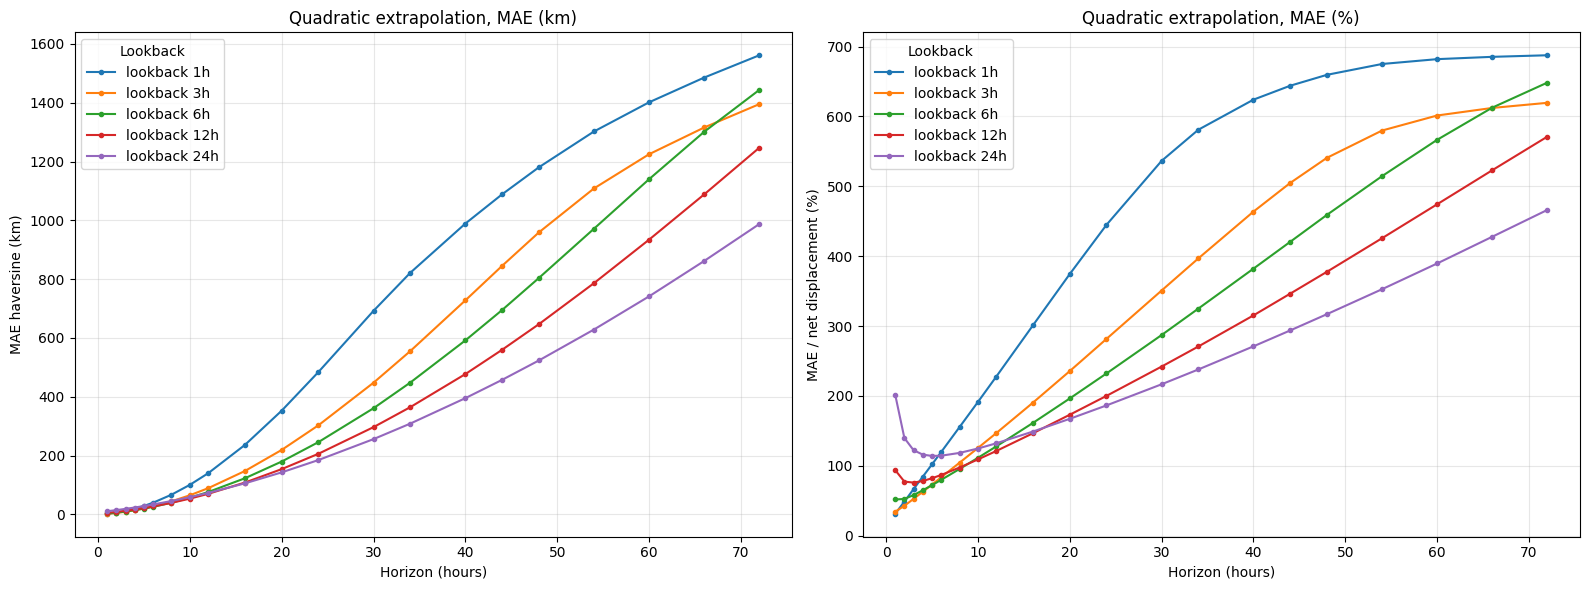

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for l in candidates_lookback:
    subset = results_quad_df[results_quad_df["lookback"] == l]
    axes[0].plot(subset["horizon"], subset["mae"], marker="o", markersize=3, label=f"lookback {l}h")
    axes[1].plot(subset["horizon"], subset["mae_pct"], marker="o", markersize=3, label=f"lookback {l}h")

axes[0].set_xlabel("Horizon (hours)")
axes[0].set_ylabel("MAE haversine (km)")
axes[0].set_title("Quadratic extrapolation, MAE (km)")
axes[0].legend(title="Lookback")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Horizon (hours)")
axes[1].set_ylabel("MAE / net displacement (%)")
axes[1].set_title("Quadratic extrapolation, MAE (%)")
axes[1].legend(title="Lookback")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
pivot_mae = results_quad_df.pivot(index="horizon", columns="lookback", values="mae").round(1)
pivot_mae.columns = [f"L={c}h" for c in pivot_mae.columns]
display(pivot_mae)

pivot_pct = results_quad_df.pivot(index="horizon", columns="lookback", values="mae_pct").round(1)
pivot_pct.columns = [f"L={c}h" for c in pivot_pct.columns]
display(pivot_pct)

,L=1h,L=3h,L=6h,L=12h,L=24h
horizon,,,,,
1,1.9,2.0,3.0,5.2,10.6
2,5.7,4.9,5.9,8.4,14.4
3,11.5,9.0,9.7,12.2,18.6
4,19.1,14.0,14.2,16.5,23.2
5,28.5,20.1,19.5,21.3,28.2
6,39.6,27.2,25.5,26.7,33.6
8,66.8,44.2,39.6,39.0,45.3
10,100.3,64.8,56.4,53.4,58.4
12,139.9,88.9,75.9,69.8,72.8


,L=1h,L=3h,L=6h,L=12h,L=24h
horizon,,,,,
1,31.4,34.4,51.9,93.9,201.9
2,48.9,42.9,52.7,77.5,139.9
3,66.8,52.8,58.3,76.1,122.4
4,84.5,62.9,65.1,78.4,116.1
5,102.1,73.2,72.4,82.3,114.2
6,119.7,83.6,79.9,86.9,114.5
8,155.4,104.5,95.5,97.6,118.5
10,191.3,125.5,111.5,109.2,124.8
12,227.6,146.8,127.8,121.3,132.3


## 4. Conclusions


- Linear extrapolation is a reasonable but limited baseline: error grows smoothly with the horizon and reaches very high levels. 
- The quadratic baseline is strictly dominated by the linear one at every horizon, even at
  its own best (long) lookback. Two causes: extrapolating curvature diverges at long
  horizons, and the least-squares parabola does not pass through the present point, adding
  error even at short horizons.
- The baselines establish that **the future position is not well described as the geometric continuation of the past trajectory's shape**. Testing models with learned parameters is the natural next step.

